# Ensemble Soft Voting — HistGradientBoostingRegressor

Trains every combination in a 4×4×5×3 = 240-model hyperparameter grid and
combines their predictions with **inverse-validation-RMSE weighting**: each
model's contribution to the ensemble is proportional to `1 / val_RMSE`,
so stronger-validating models dominate the average.

Saves test-set predictions to `results/soft_voting_preds.npy` for
`model_comparison.ipynb`.

**Metrics scale:** monthly log-diff × 100 (percentage points of monthly PCE inflation).


In [15]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow._api.v2.experimental.numpy import random

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from fred_md_utils import configure_plots, default_paths, get_splits

configure_plots()
VINTAGE_DIR, RESULTS_DIR = default_paths()


## Load splits

In [16]:
vintage_file, X_train, y_train, X_val, y_val, X_test, y_test, feature_names = get_splits(
    VINTAGE_DIR, horizon=1, n_lags=0,
)
print(f"Features: {len(feature_names)}  Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")


  2026-04-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-03-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  768 obs  1959-01-01 -> 2022-12-01
  Val   :   29 obs  2023-01-01 -> 2025-05-01
  Test  :    7 obs  2025-06-01 -> 2025-12-01
  Features: 126 (126 base × 1 time steps)
Features: 126  Train/Val/Test: 768/29/7


## Train full grid and collect per-model val/test predictions

In [17]:
max_iter_grid         = [100, 500, 1000, 2500]
learning_rate_grid    = [0.01, 0.05, 0.1, 0.2]
max_leaf_nodes_grid   = [10, 20, 30, 40, 50]
min_samples_leaf_grid = [10, 20, 50]

val_preds_list  = []
test_preds_list = []
val_rmses       = []
configs         = []

n_total = (len(max_iter_grid) * len(learning_rate_grid)
           * len(max_leaf_nodes_grid) * len(min_samples_leaf_grid))
print(f"Training {n_total} HistGradientBoostingRegressor models...")

for mi, lr, mln, msl in product(max_iter_grid, learning_rate_grid,
                                 max_leaf_nodes_grid, min_samples_leaf_grid):
    model = HistGradientBoostingRegressor(
        max_iter=mi, learning_rate=lr,
        max_leaf_nodes=mln, min_samples_leaf=msl,
        l2_regularization=0.1,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25,
        random_state=int(random.randint(0, 100)),
    )
    model.fit(X_train, y_train)
    vp = model.predict(X_val)
    tp = model.predict(X_test)
    val_preds_list.append(vp)
    test_preds_list.append(tp)
    val_rmses.append(float(np.sqrt(mean_squared_error(y_val, vp))))
    configs.append({'max_iter': mi, 'learning_rate': lr,
                    'max_leaf_nodes': mln, 'min_samples_leaf': msl})

    if len(configs) % 20 == 0:
        print(f"  {len(configs)}/{n_total} done")

val_preds_arr  = np.stack(val_preds_list)
test_preds_arr = np.stack(test_preds_list)
val_rmses      = np.array(val_rmses)
print(f"Finished {len(configs)} models.")


Training 240 HistGradientBoostingRegressor models...
  20/240 done
  40/240 done
  60/240 done
  80/240 done
  100/240 done
  120/240 done
  140/240 done
  160/240 done
  180/240 done
  200/240 done
  220/240 done
  240/240 done
Finished 240 models.


## Combine with inverse-val-RMSE weights

In [18]:
weights = 1.0 / val_rmses
weights = weights / weights.sum()

ensemble_val_pred  = np.average(val_preds_arr,  axis=0, weights=weights)
ensemble_test_pred = np.average(test_preds_arr, axis=0, weights=weights)

# Equal-weight baseline for reference
equal_val_pred  = val_preds_arr.mean(axis=0)
equal_test_pred = test_preds_arr.mean(axis=0)

print(f"Individual val RMSE: min={val_rmses.min():.4f}  "
      f"median={np.median(val_rmses):.4f}  max={val_rmses.max():.4f}")
print(f"Equal-weight   val RMSE: {np.sqrt(mean_squared_error(y_val, equal_val_pred)):.4f}")
print(f"Weighted  val RMSE (soft vote): "
      f"{np.sqrt(mean_squared_error(y_val, ensemble_val_pred)):.4f}")


Individual val RMSE: min=0.0862  median=0.1354  max=0.2471
Equal-weight   val RMSE: 0.1173
Weighted  val RMSE (soft vote): 0.1115


### Top 10 configs by validation RMSE

In [19]:
top_df = (
    pd.DataFrame(configs)
      .assign(val_rmse=val_rmses, weight=weights)
      .sort_values('val_rmse')
      .head(10)
      .reset_index(drop=True)
)
print(top_df.to_string(index=False, float_format='{:.4f}'.format))


 max_iter  learning_rate  max_leaf_nodes  min_samples_leaf  val_rmse  weight
      100         0.0500              40                10    0.0862  0.0065
     2500         0.0500              50                50    0.0934  0.0060
     2500         0.0100              20                50    0.0934  0.0060
     2500         0.0500              30                10    0.0945  0.0060
      500         0.0500              30                20    0.0946  0.0060
      100         0.0100              40                10    0.0955  0.0059
     2500         0.1000              50                10    0.0956  0.0059
     1000         0.1000              50                10    0.0967  0.0058
     1000         0.0500              20                10    0.0979  0.0058
      100         0.1000              40                10    0.0983  0.0057


## Test-set metrics

In [20]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R²':   float(r2_score(y_true, y_pred)),
        'MAPE': float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100),
    }

val_m  = metrics(y_val,  ensemble_val_pred)
test_m = metrics(y_test, ensemble_test_pred)
naive_rmse = float(np.sqrt(mean_squared_error(y_val.iloc[1:], y_val.shift(1).dropna())))

print(f"Val  : RMSE={val_m['RMSE']:.4f}  MAE={val_m['MAE']:.4f}  R²={val_m['R²']:.4f}  MAPE={val_m['MAPE']:.2f}%")
print(f"Test : RMSE={test_m['RMSE']:.4f}  MAE={test_m['MAE']:.4f}  R²={test_m['R²']:.4f}  MAPE={test_m['MAPE']:.2f}%")
print(f"Naive RW (val reference) RMSE: {naive_rmse:.4f}")


Val  : RMSE=0.1115  MAE=0.0931  R²=0.1399  MAPE=202.93%
Test : RMSE=0.0999  MAE=0.0855  R²=-2.0611  MAPE=32.31%
Naive RW (val reference) RMSE: 0.1661


## Plot actual vs predicted

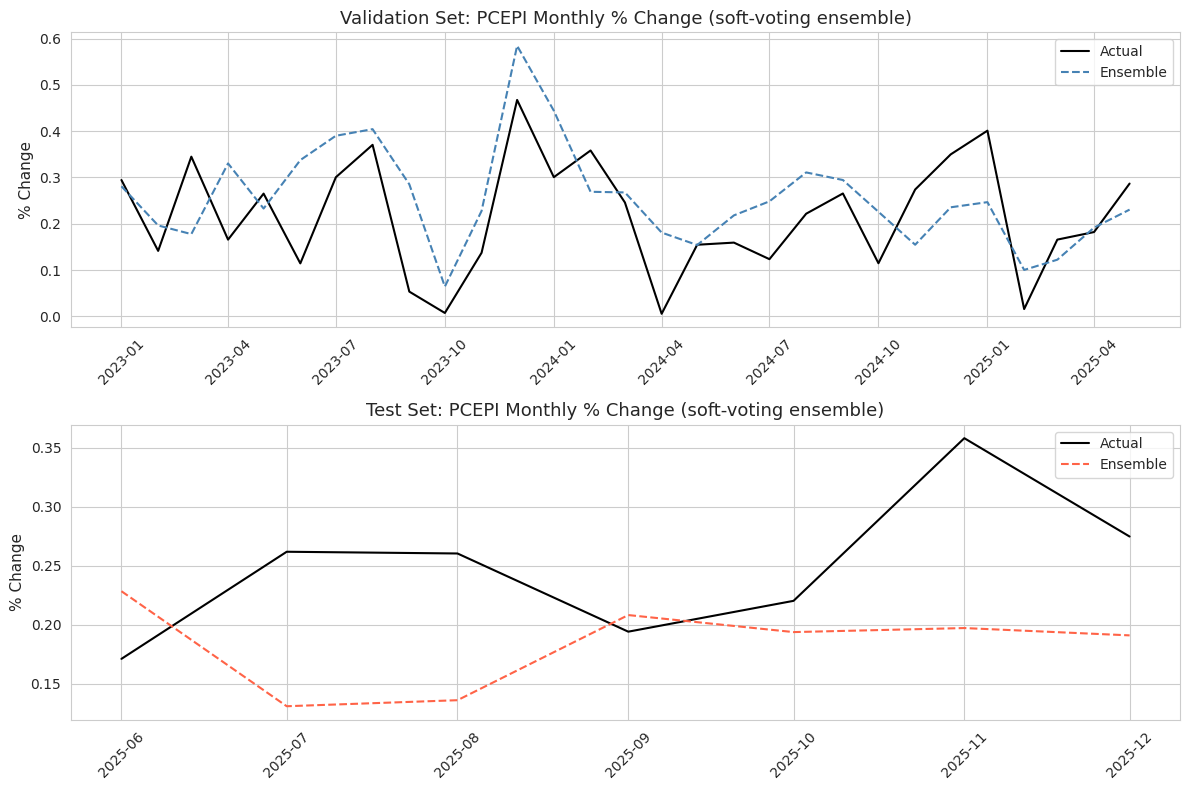

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(y_val.index, y_val.values,          label='Actual',    color='black')
axes[0].plot(y_val.index, ensemble_val_pred,     label='Ensemble',  color='steelblue', linestyle='--')
axes[0].set_title('Validation Set: PCEPI Monthly % Change (soft-voting ensemble)')
axes[0].set_ylabel('% Change'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(y_test.index, y_test.values,         label='Actual',    color='black')
axes[1].plot(y_test.index, ensemble_test_pred,    label='Ensemble',  color='tomato', linestyle='--')
axes[1].set_title('Test Set: PCEPI Monthly % Change (soft-voting ensemble)')
axes[1].set_ylabel('% Change'); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Save test predictions for `model_comparison.ipynb`

In [22]:
os.makedirs(RESULTS_DIR, exist_ok=True)
np.save(os.path.join(RESULTS_DIR, 'soft_voting_preds.npy'), np.asarray(ensemble_test_pred))
np.save(os.path.join(RESULTS_DIR, 'soft_voting_dates.npy'),
        np.array(y_test.index, dtype='datetime64[ns]'))
print(f"Saved {len(ensemble_test_pred)} soft-voting predictions to {RESULTS_DIR}/soft_voting_preds.npy")
print(f"  {y_test.index.min().date()} -> {y_test.index.max().date()}")


Saved 7 soft-voting predictions to results/soft_voting_preds.npy
  2025-06-01 -> 2025-12-01
